In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_curve, auc, accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [36]:
df = pd.read_csv('/content/Student Stress Factors.csv')

# Remove emojis from column names
df.columns = df.columns.str.replace(r'[^\w\s]', '', regex=True)

**EDA**

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 6 columns):
 #   Column                                                          Non-Null Count  Dtype
---  ------                                                          --------------  -----
 0   Kindly Rate your Sleep Quality                                  520 non-null    int64
 1   How many times a week do you suffer headaches                   520 non-null    int64
 2   How would you rate you academic performance                     520 non-null    int64
 3   how would you rate your study load                              520 non-null    int64
 4   How many times a week you practice extracurricular activities   520 non-null    int64
 5   How would you rate your stress levels                           520 non-null    int64
dtypes: int64(6)
memory usage: 24.5 KB


In [38]:
display(df.head(10))

,Kindly Rate your Sleep Quality,How many times a week do you suffer headaches,How would you rate you academic performance,how would you rate your study load,How many times a week you practice extracurricular activities,How would you rate your stress levels
0,3,1,3,4,2,3
1,4,1,2,3,3,2
2,2,1,2,1,4,4
3,3,2,3,2,3,3
4,2,3,1,5,5,3
5,3,1,3,2,1,1
6,3,5,1,4,3,5
7,4,3,1,4,1,1
8,2,1,4,4,5,1
9,1,2,3,2,5,2


In [39]:
print(df.columns)

Index(['Kindly Rate your Sleep Quality ',
       'How many times a week do you suffer headaches ',
       'How would you rate you academic performance ',
       'how would you rate your study load',
       'How many times a week you practice extracurricular activities ',
       'How would you rate your stress levels'],
      dtype='object')


**1. Code to check for null values in every column**

In [40]:

null_counts = df.isnull().sum()
print(null_counts)

if null_counts.sum() == 0:
    print("There are no null values in the dataframe.")

Kindly Rate your Sleep Quality                                    0
How many times a week do you suffer headaches                     0
How would you rate you academic performance                       0
how would you rate your study load                                0
How many times a week you practice extracurricular activities     0
How would you rate your stress levels                             0
dtype: int64
There are no null values in the dataframe.


**2. Exploratory Data Analysis (EDA)**

---


Checking structure, missing values, and get an initial sense of your data distribution for key categorical columns.

In [41]:


print(df.info())                                # Checks data types and non-null counts
print(df.head())                                # Shows first five rows
print(df.isnull().sum())                        # Checks count of nulls per column
print(df.describe())                            # Summary stats for numeric columns
print(df['How many times a week do you suffer headaches '].value_counts())     # Frequency of seniority levels
print(df['Kindly Rate your Sleep Quality '].value_counts())            # Frequency of locations

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 6 columns):
 #   Column                                                          Non-Null Count  Dtype
---  ------                                                          --------------  -----
 0   Kindly Rate your Sleep Quality                                  520 non-null    int64
 1   How many times a week do you suffer headaches                   520 non-null    int64
 2   How would you rate you academic performance                     520 non-null    int64
 3   how would you rate your study load                              520 non-null    int64
 4   How many times a week you practice extracurricular activities   520 non-null    int64
 5   How would you rate your stress levels                           520 non-null    int64
dtypes: int64(6)
memory usage: 24.5 KB
None
   Kindly Rate your Sleep Quality   \
0                                3   
1                                4   
2         

 **Encoding Values**#

**3. Select Features and Target**

In [42]:

features = [
    'Kindly Rate your Sleep Quality',
    'How many times a week do you suffer headaches?',
    'How would you rate your academic performance?',
    'How would you rate your study load?',
    'How many times a week do you practice extracurricular activities?'
]
target = 'How would you rate your stress levels?'

**4. Check for columns that could be treated as categorical based on unique values and data type**


In [43]:
categorical_cols = []
for col in df.columns:
    if df[col].dtype == 'int64' and df[col].nunique() < 10: # Assuming columns with less than 10 unique integer values are categorical
        categorical_cols.append(col)

print("Columns that could be treated as categorical:")
print(categorical_cols)

Columns that could be treated as categorical:
['Kindly Rate your Sleep Quality ', 'How many times a week do you suffer headaches ', 'How would you rate you academic performance ', 'how would you rate your study load', 'How many times a week you practice extracurricular activities ', 'How would you rate your stress levels']


**5. Identify columns to one-hot encode**

In [44]:

categorical_cols_to_encode = categorical_cols # Using the list generated in the previous step

# Perform one-hot encoding
# pd.get_dummies = pandas function that converts categorical variables into dummy/indicator variables.
df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode)    #

display(df_encoded.head())

,Kindly Rate your Sleep Quality _1,Kindly Rate your Sleep Quality _2,Kindly Rate your Sleep Quality _3,Kindly Rate your Sleep Quality _4,Kindly Rate your Sleep Quality _5,How many times a week do you suffer headaches _1,How many times a week do you suffer headaches _2,How many times a week do you suffer headaches _3,How many times a week do you suffer headaches _4,How many times a week do you suffer headaches _5,...,How many times a week you practice extracurricular activities _1,How many times a week you practice extracurricular activities _2,How many times a week you practice extracurricular activities _3,How many times a week you practice extracurricular activities _4,How many times a week you practice extracurricular activities _5,How would you rate your stress levels_1,How would you rate your stress levels_2,How would you rate your stress levels_3,How would you rate your stress levels_4,How would you rate your stress levels_5
0,False,False,True,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
1,False,False,False,True,False,True,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
2,False,True,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3,False,False,True,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
4,False,True,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False


**6. Select features (X) and target (y)**

In [45]:

X = df_encoded.drop(columns=[col for col in df_encoded.columns if 'How would you rate your stress levels' in col])
y = df['How would you rate your stress levels']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (520, 25)
Target (y) shape: (520,)


**7. Split the data into training and testing sets**

In [46]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (416, 25)
X_test shape: (104, 25)
y_train shape: (416,)
y_test shape: (104,)


**8. Standardizing the features using Standard Scaler**

In [47]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the scaler on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the fitted scaler
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (416, 25)
X_test_scaled shape: (104, 25)


**9.Use SMOTE to oversample the minority class in the training data**

In [48]:

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Shape of X_train_resampled:", X_train_resampled.shape)
print("Shape of y_train_resampled:", y_train_resampled.shape)
print("Value counts of y_train_resampled:\n", y_train_resampled.value_counts())

Shape of X_train_resampled: (500, 25)
Shape of y_train_resampled: (500,)
Value counts of y_train_resampled:
 How would you rate your stress levels
3    100
4    100
2    100
1    100
5    100
Name: count, dtype: int64


**10. Training Logistic Regression Model**

In [49]:
model = LogisticRegression()
model.fit(X_train_resampled, y_train_resampled)

LogisticRegression()

**11. Make predictions on the test set**

In [50]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# You can also calculate other metrics like precision, recall, F1-score, etc. depending on your needs.
# For example, for F1-score:
f1 = f1_score(y_test, y_pred, average='weighted') # Use 'weighted' for multiclass classification
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.49
F1 Score: 0.49


In [51]:
print("Latest predictions (first 10):")
print(y_pred_tuned[:10])

Latest predictions (first 10):
[4 1 5 3 1 5 3 2 4 5]


**11. Make predictions on the test set**

In [52]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# You can also calculate other metrics like precision, recall, F1-score, etc. depending on your needs.
# For example, for F1-score:
f1 = f1_score(y_test, y_pred, average='weighted') # Use 'weighted' for multiclass classification
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.49
F1 Score: 0.49


**Create a count plot to visualize the distribution of stress levels.**

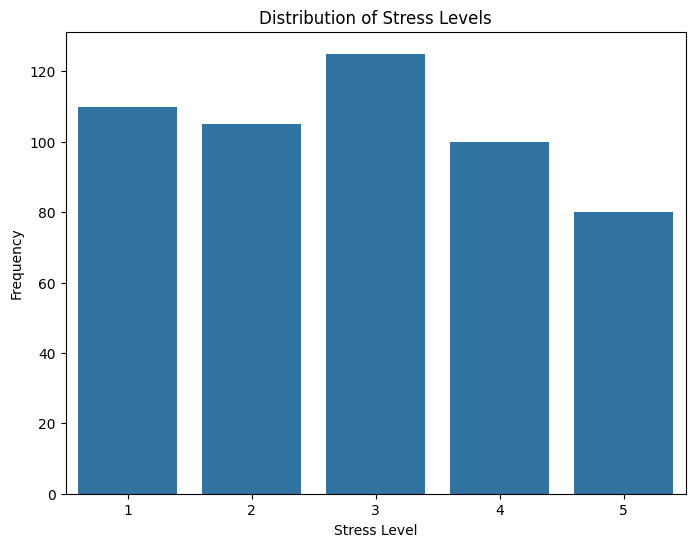

In [53]:
plt.figure(figsize=(8, 6))
sns.countplot(x='How would you rate your stress levels', data=df)
plt.title('Distribution of Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('Frequency')
plt.show()

## Visualize the relationship between sleep quality and stress levels

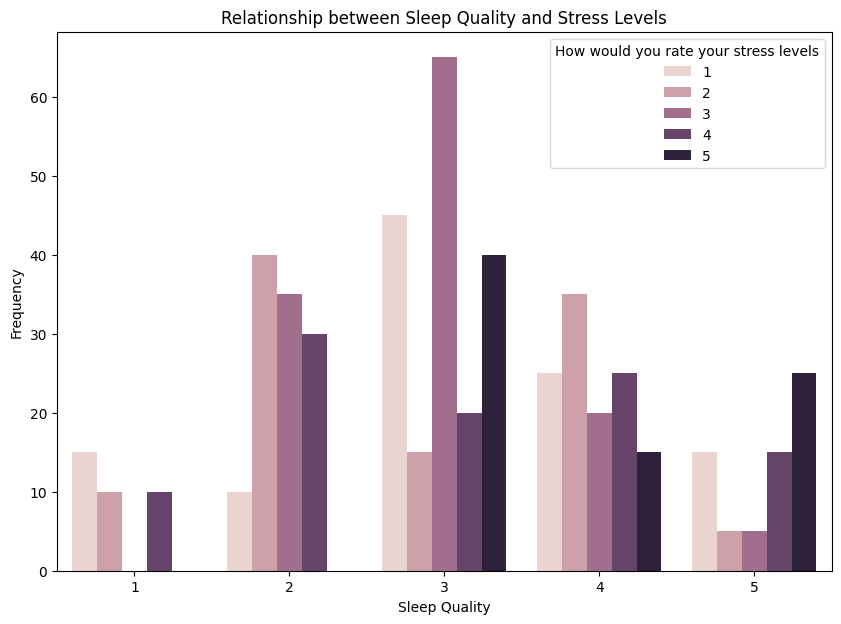

In [54]:
plt.figure(figsize=(10, 7))
sns.countplot(x='Kindly Rate your Sleep Quality ', hue='How would you rate your stress levels', data=df)
plt.title('Relationship between Sleep Quality and Stress Levels')
plt.xlabel('Sleep Quality')
plt.ylabel('Frequency')
plt.show()

## Visualize the relationship between headaches and stress levels

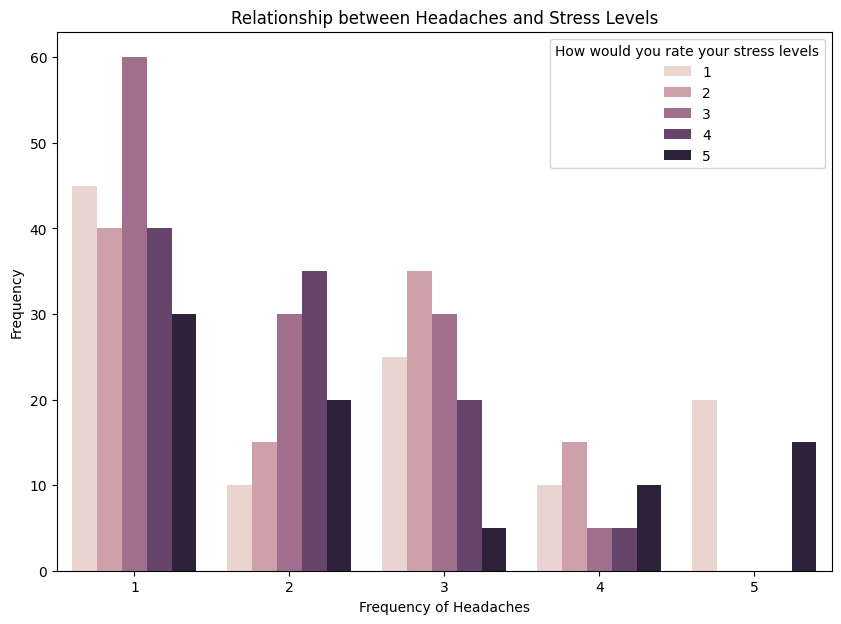

In [55]:
plt.figure(figsize=(10, 7))
sns.countplot(x='How many times a week do you suffer headaches ', hue='How would you rate your stress levels', data=df)
plt.title('Relationship between Headaches and Stress Levels')
plt.xlabel('Frequency of Headaches')
plt.ylabel('Frequency')
plt.show()

## Visualize the relationship between academic performance and stress levels

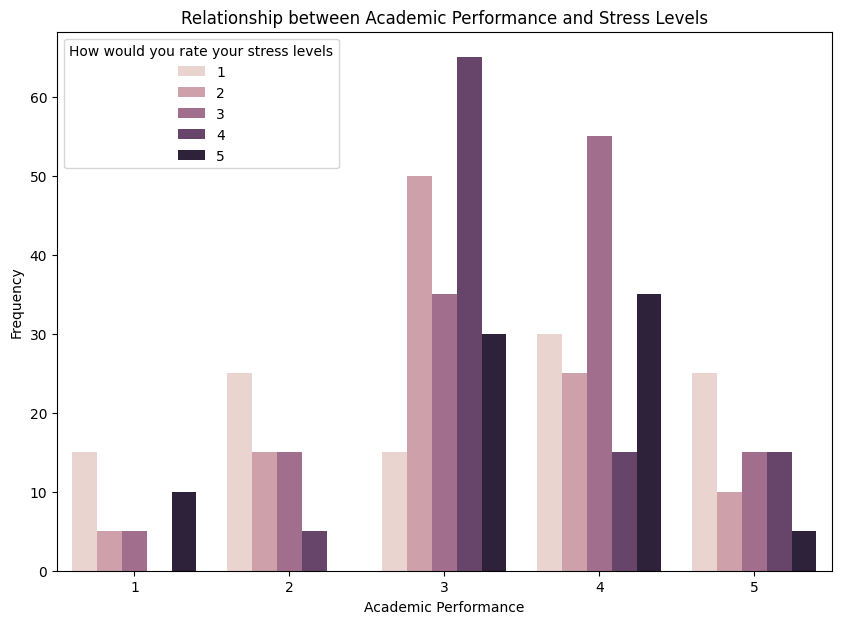

In [56]:
plt.figure(figsize=(10, 7))
sns.countplot(x='How would you rate you academic performance ', hue='How would you rate your stress levels', data=df)
plt.title('Relationship between Academic Performance and Stress Levels')
plt.xlabel('Academic Performance')
plt.ylabel('Frequency')
plt.show()

## Visualize the relationship between study load and stress levels

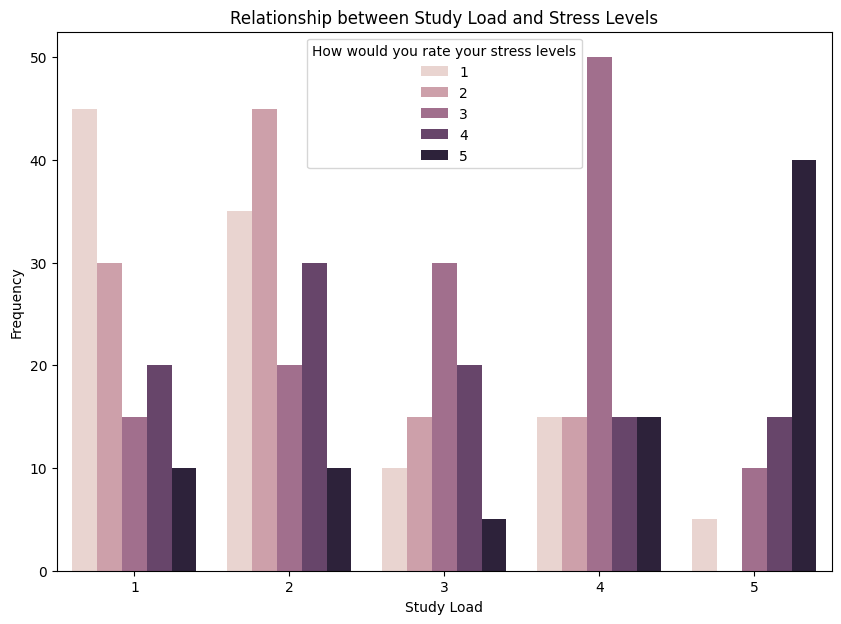

In [57]:
plt.figure(figsize=(10, 7))
sns.countplot(x='how would you rate your study load', hue='How would you rate your stress levels', data=df)
plt.title('Relationship between Study Load and Stress Levels')
plt.xlabel('Study Load')
plt.ylabel('Frequency')
plt.show()

## Visualize the relationship between extracurricular activities and stress levels

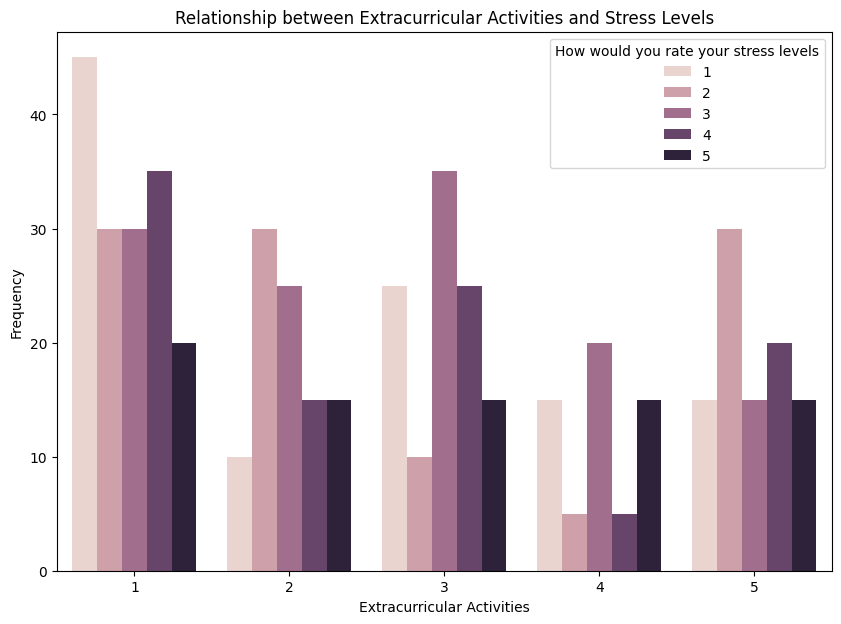

In [58]:
plt.figure(figsize=(10, 7))
sns.countplot(x='How many times a week you practice extracurricular activities ', hue='How would you rate your stress levels', data=df)
plt.title('Relationship between Extracurricular Activities and Stress Levels')
plt.xlabel('Extracurricular Activities')
plt.ylabel('Frequency')
plt.show()

## Visualize correlations between numerical features using heatmap.

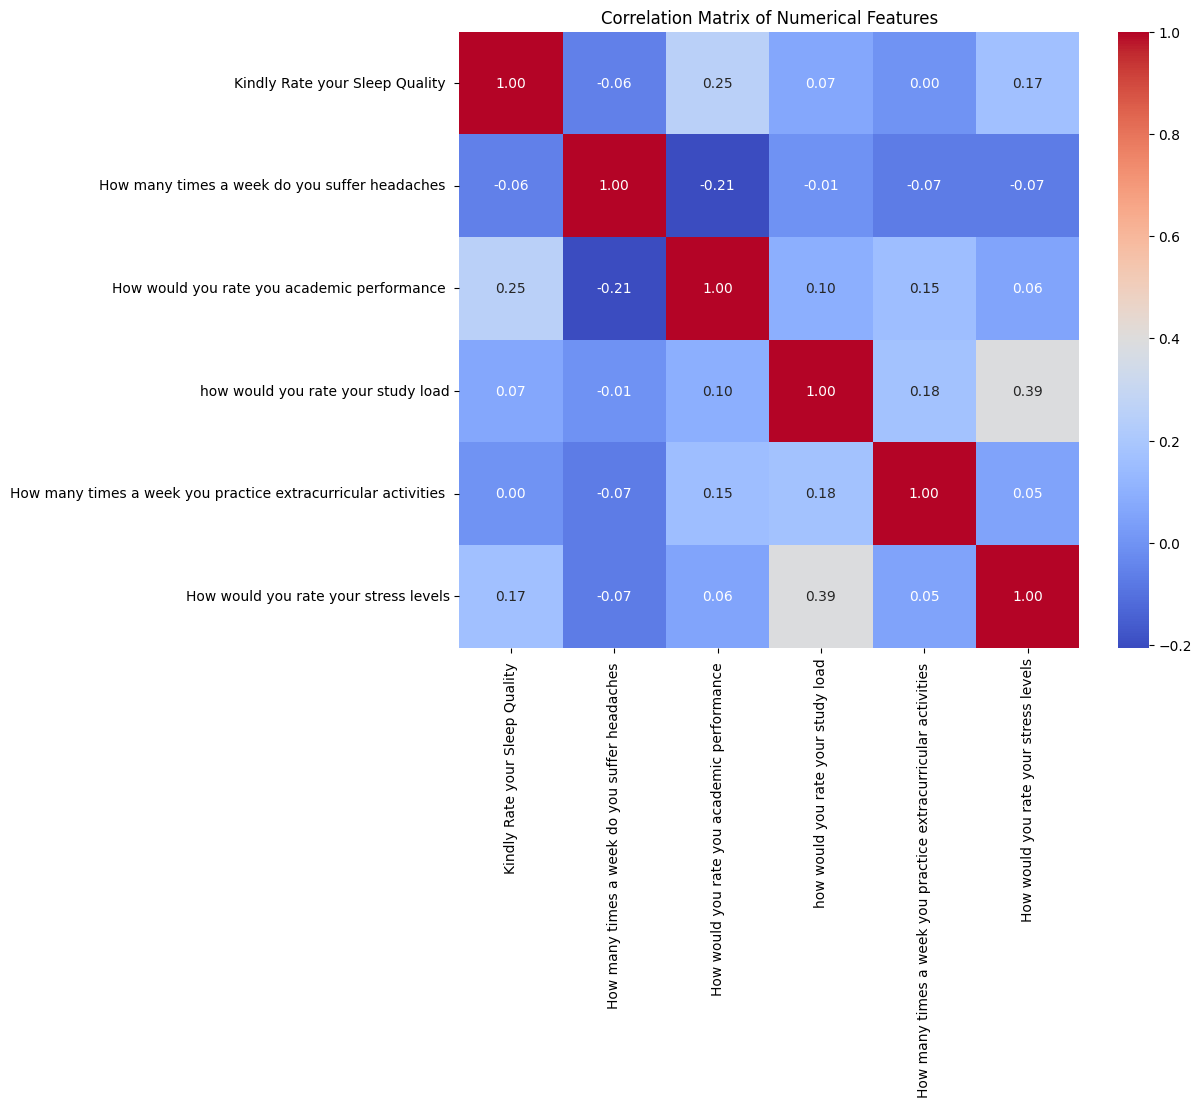

In [59]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**KNN's**

In [60]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

# Initialize the KNN model (you can choose a different number of neighbors)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the KNN model on the resampled training data
knn_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the scaled test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate the KNN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

print(f"KNN Accuracy: {accuracy_knn:.2f}")
print(f"KNN F1 Score: {f1_knn:.2f}")

KNN Accuracy: 0.88
KNN F1 Score: 0.89


In [61]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l1', 'l2'],              # Regularization penalty
    'solver': ['liblinear', 'saga'],     # Algorithm to use in the optimization problem
    'max_iter': [100, 500, 1000, 2000]          # Maximum number of iterations taken for the solvers to converge
}

In [62]:
# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=LogisticRegression(random_state=42),
                           param_grid=param_grid,
                           cv=5,          # Use 5-fold cross-validation
                           scoring='accuracy', # Use accuracy as the scoring metric
                           n_jobs=-1)      # Use all available CPU cores

In [63]:
# Perform hyperparameter tuning
grid_search.fit(X_train_resampled, y_train_resampled)

# Print the best hyperparameters found
print("Best hyperparameters:", grid_search.best_params_)

Best hyperparameters: {'C': 1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [64]:
# Get the best hyperparameters from GridSearchCV
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

# Train a new Logistic Regression model with the best hyperparameters
best_model = LogisticRegression(random_state=42, **best_params)
best_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set using the best model
y_pred_tuned = best_model.predict(X_test_scaled)

# Evaluate the performance of the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted')

print(f"Accuracy with tuned hyperparameters: {accuracy_tuned:.2f}")
print(f"F1 Score with tuned hyperparameters: {f1_tuned:.2f}")

Best hyperparameters: {'C': 1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Accuracy with tuned hyperparameters: 0.49
F1 Score with tuned hyperparameters: 0.48


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [65]:
print("Latest predictions (first 10):")
print(y_pred_tuned[:10])

Latest predictions (first 10):
[4 1 5 3 1 5 3 2 4 5]


In [66]:
# Get the best hyperparameters from GridSearchCV
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

# Train a new Logistic Regression model with the best hyperparameters
best_model = LogisticRegression(random_state=42, **best_params)
best_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set using the best model
y_pred_tuned = best_model.predict(X_test_scaled)

# Evaluate the performance of the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted')

print(f"Accuracy with tuned hyperparameters: {accuracy_tuned:.2f}")
print(f"F1 Score with tuned hyperparameters: {f1_tuned:.2f}")

Best hyperparameters: {'C': 1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Accuracy with tuned hyperparameters: 0.49
F1 Score with tuned hyperparameters: 0.48


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [67]:
# Perform hyperparameter tuning
grid_search.fit(X_train_resampled, y_train_resampled)

# Print the best hyperparameters found
print("Best hyperparameters:", grid_search.best_params_)

Best hyperparameters: {'C': 1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [68]:
# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=LogisticRegression(random_state=42),
                           param_grid=param_grid,
                           cv=5,          # Use 5-fold cross-validation
                           scoring='accuracy', # Use accuracy as the scoring metric
                           n_jobs=-1)      # Use all available CPU cores

In [69]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l1', 'l2'],              # Regularization penalty
    'solver': ['liblinear', 'saga'],     # Algorithm to use in the optimization problem
    'max_iter': [100, 500, 1000, 2000]          # Maximum number of iterations taken for the solvers to converge
}


**Create a count plot to visualize the distribution of stress levels.**



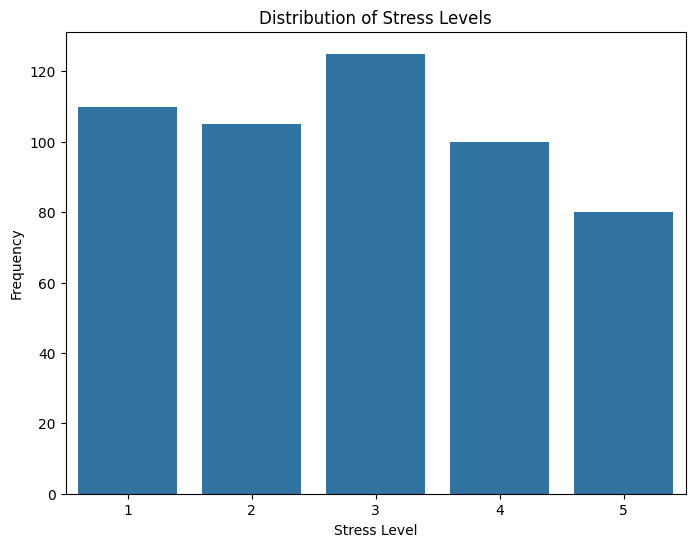

In [70]:
plt.figure(figsize=(8, 6))
sns.countplot(x='How would you rate your stress levels', data=df)
plt.title('Distribution of Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('Frequency')
plt.show()

## Visualize the relationship between sleep quality and stress levels



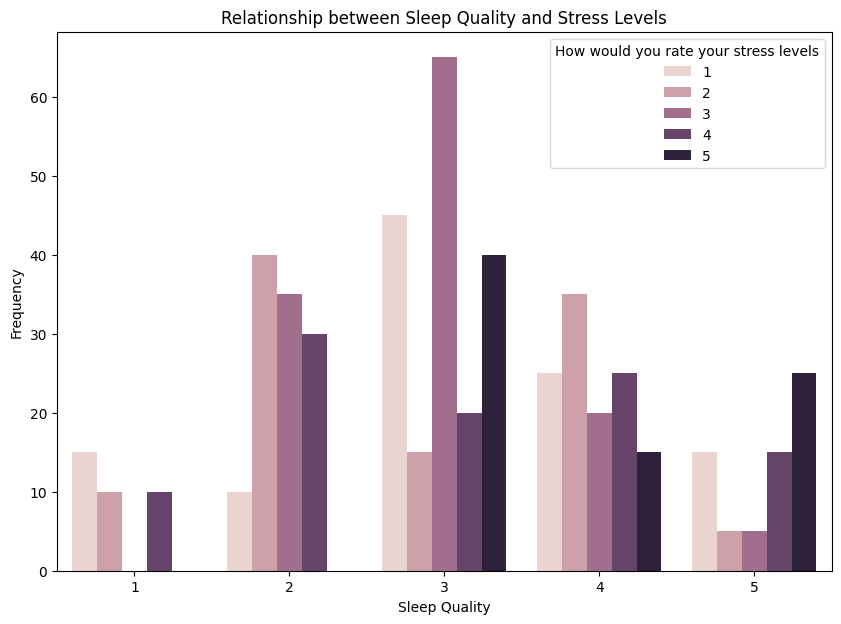

In [71]:
plt.figure(figsize=(10, 7))
sns.countplot(x='Kindly Rate your Sleep Quality ', hue='How would you rate your stress levels', data=df)
plt.title('Relationship between Sleep Quality and Stress Levels')
plt.xlabel('Sleep Quality')
plt.ylabel('Frequency')
plt.show()

## Visualize the relationship between headaches and stress levels



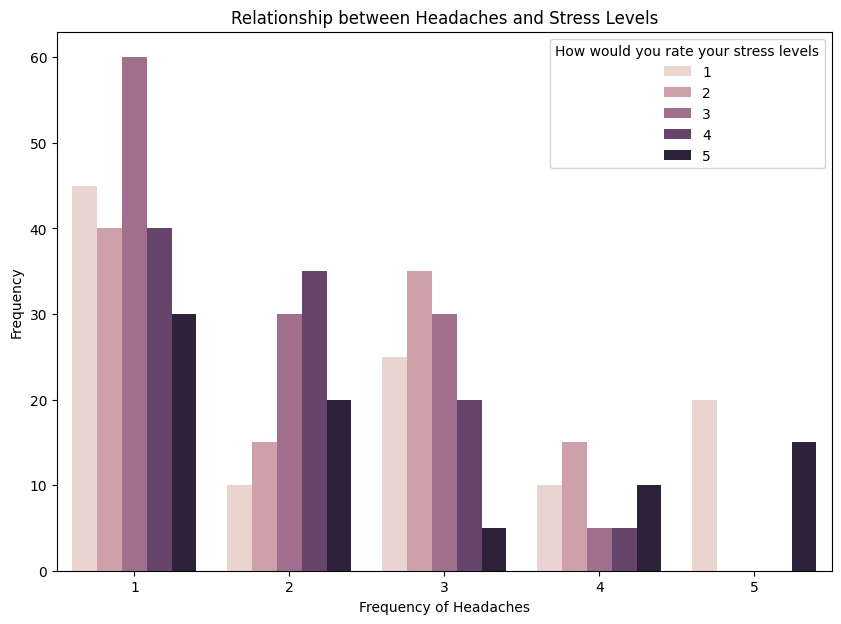

In [72]:
plt.figure(figsize=(10, 7))
sns.countplot(x='How many times a week do you suffer headaches ', hue='How would you rate your stress levels', data=df)
plt.title('Relationship between Headaches and Stress Levels')
plt.xlabel('Frequency of Headaches')
plt.ylabel('Frequency')
plt.show()

## Visualize the relationship between academic performance and stress levels




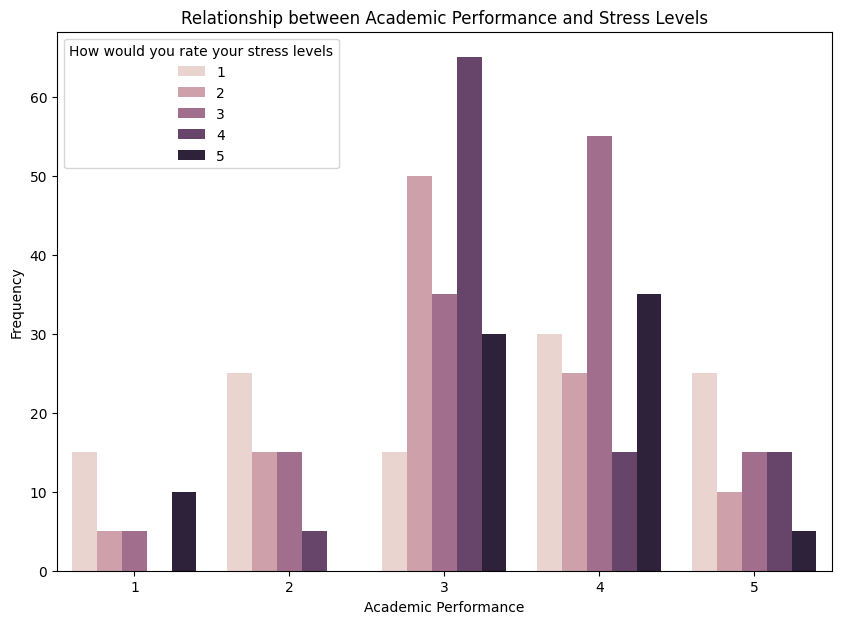

In [73]:
plt.figure(figsize=(10, 7))
sns.countplot(x='How would you rate you academic performance ', hue='How would you rate your stress levels', data=df)
plt.title('Relationship between Academic Performance and Stress Levels')
plt.xlabel('Academic Performance')
plt.ylabel('Frequency')
plt.show()

## Visualize the relationship between study load and stress levels



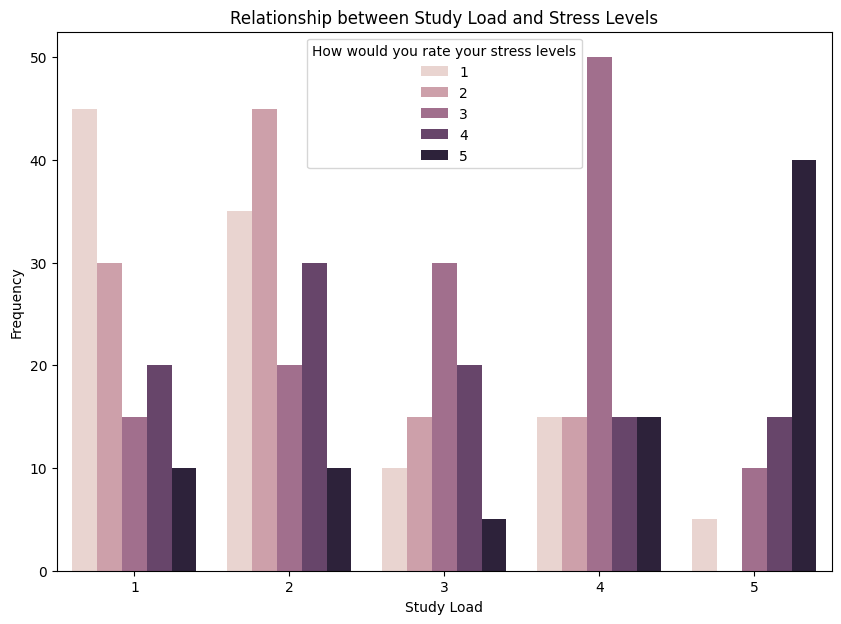

In [74]:
plt.figure(figsize=(10, 7))
sns.countplot(x='how would you rate your study load', hue='How would you rate your stress levels', data=df)
plt.title('Relationship between Study Load and Stress Levels')
plt.xlabel('Study Load')
plt.ylabel('Frequency')
plt.show()

## Visualize the relationship between extracurricular activities and stress levels



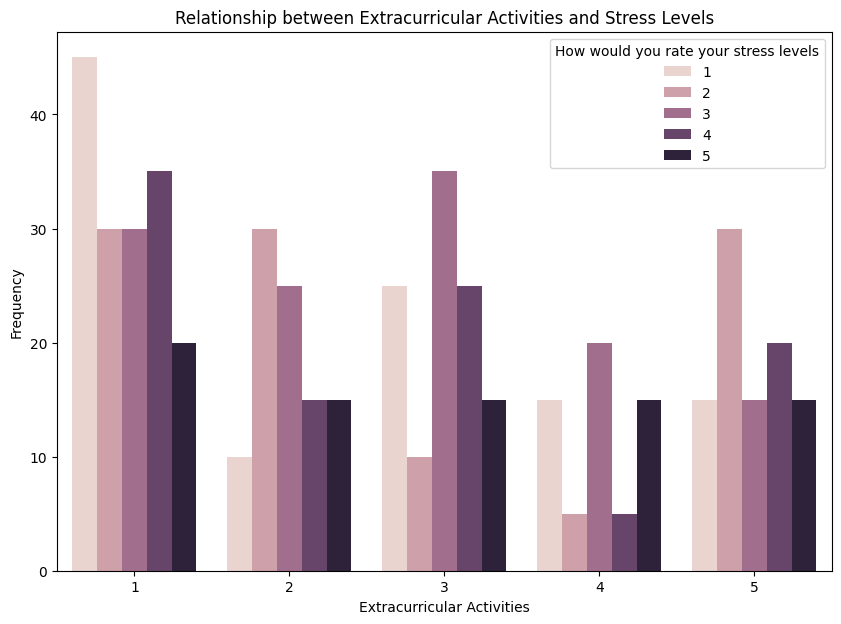

In [75]:
plt.figure(figsize=(10, 7))
sns.countplot(x='How many times a week you practice extracurricular activities ', hue='How would you rate your stress levels', data=df)
plt.title('Relationship between Extracurricular Activities and Stress Levels')
plt.xlabel('Extracurricular Activities')
plt.ylabel('Frequency')
plt.show()

## Visualize correlations between numerical features using heatmap.



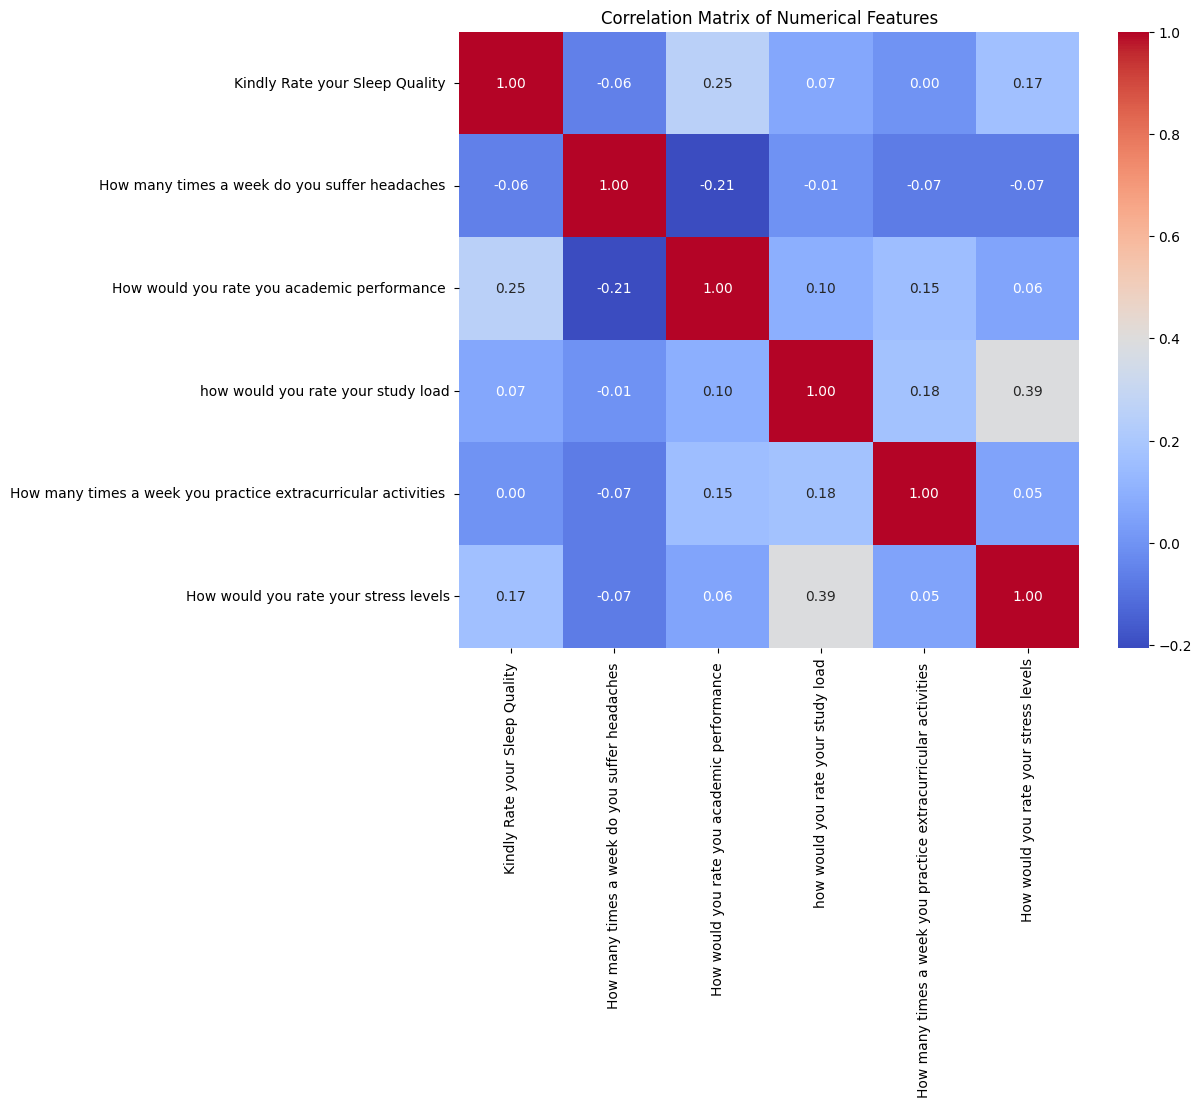

In [76]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**KNN's**

In [78]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

# Initialize the KNN model (you can choose a different number of neighbors)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the KNN model on the resampled training data
knn_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the scaled test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate the KNN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

print(f"KNN Accuracy: {accuracy_knn:.2f}")
print(f"KNN F1 Score: {f1_knn:.2f}")
print(f"Latest predictions (first 10):")
print(y_pred_tuned[:10])

KNN Accuracy: 0.88
KNN F1 Score: 0.89
Latest predictions (first 10):
[4 1 5 3 1 5 3 2 4 5]


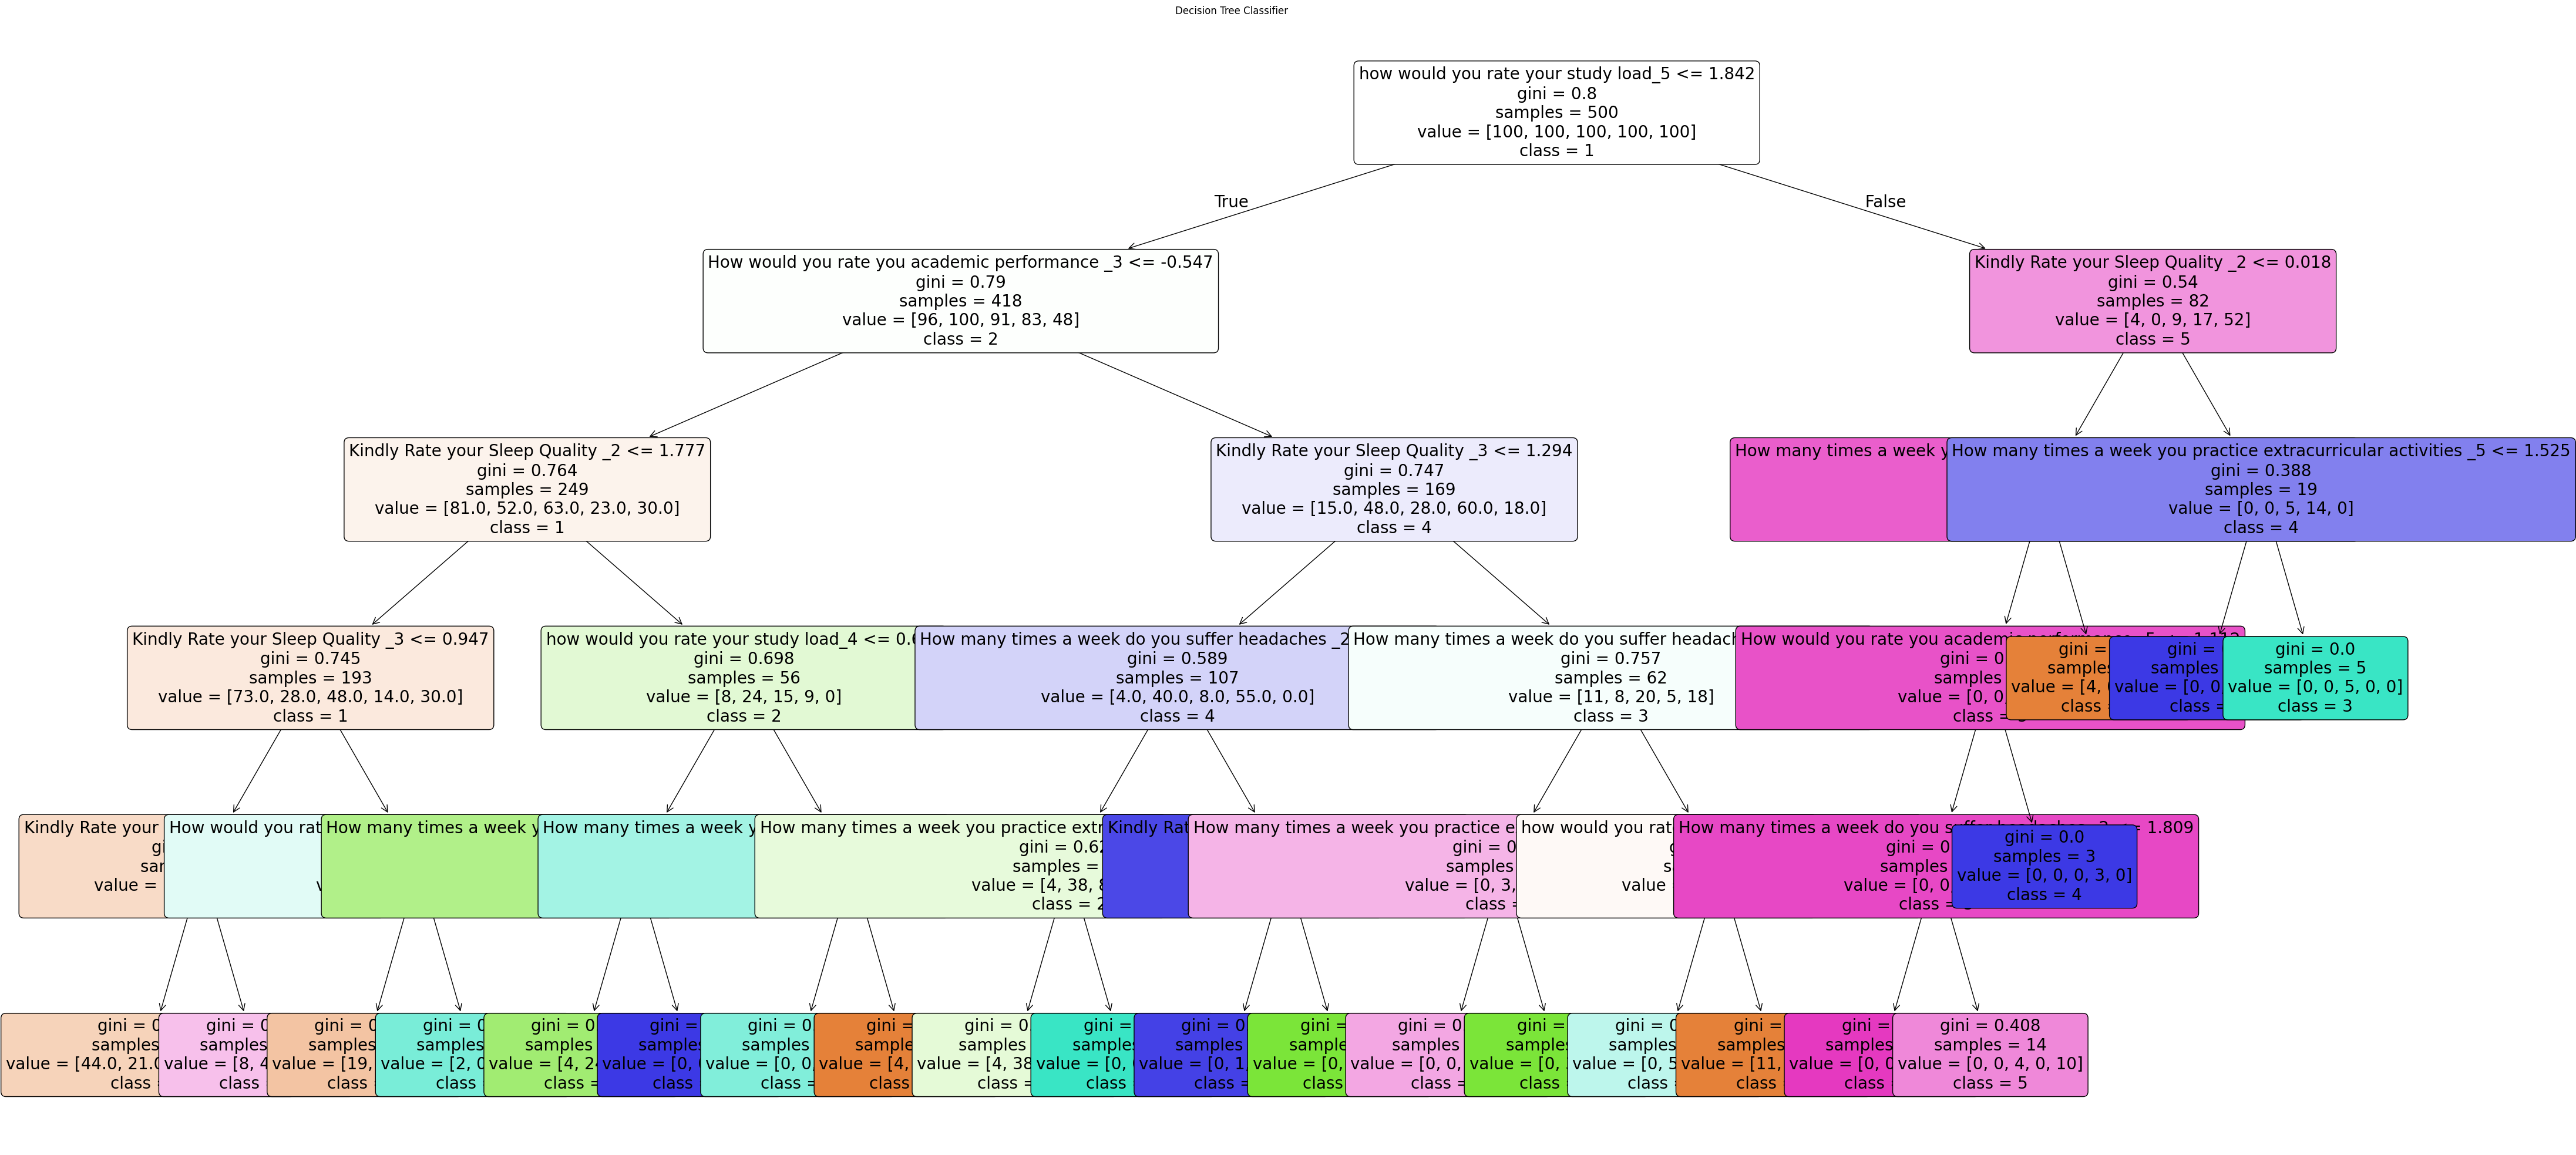

Decision Tree Accuracy: 0.58
Decision Tree F1 Score: 0.58
classification_report (217    2
20     2
306    3
175    2
346    2
      ..
390    3
330    3
48     3
425    2
8      1
Name: How would you rate your stress levels, Length: 104, dtype: int64, array([4, 1, 5, 3, 1, 5, 3, 2, 4, 5, 3, 5, 3, 5, 3, 5, 1, 5, 5, 1, 5, 3,
       1, 5, 1, 3, 1, 4, 5, 5, 4, 5, 2, 1, 2, 1, 1, 2, 4, 4, 1, 1, 5, 1,
       3, 2, 3, 3, 2, 5, 2, 3, 3, 3, 5, 4, 4, 2, 3, 4, 4, 5, 1, 4, 4, 3,
       5, 1, 1, 3, 4, 4, 5, 1, 1, 4, 1, 5, 3, 4, 1, 2, 1, 4, 1, 2, 2, 1,
       1, 1, 3, 1, 1, 1, 3, 1, 5, 3, 5, 2, 2, 3, 4, 3]))


In [90]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Initialize and train a Decision Tree Classifier
# You can change the value of max_depth to control the depth of the tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_resampled, y_train_resampled)

# Visualize the decision tree
plt.figure(figsize=(50, 25)) # Increased figure size
plot_tree(dt_model, feature_names=X.columns, class_names=[str(i) for i in sorted(y.unique())], filled=True, rounded=True, fontsize=20)
plt.title('Decision Tree Classifier')
plt.show()

# Make predictions on the test set using the Decision Tree model
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluate the Decision Tree model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print(f"Decision Tree Accuracy: {accuracy_dt:.2f}")
print(f"Decision Tree F1 Score: {f1_dt:.2f}")
print(f"classification_report", (y_test, y_pred))

**Random Forest**

In [92]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report # Import classification_report

rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8173076923076923
              precision    recall  f1-score   support

           1       0.68      0.86      0.76        22
           2       1.00      0.81      0.89        21
           3       0.88      0.88      0.88        25
           4       0.68      0.75      0.71        20
           5       1.00      0.75      0.86        16

    accuracy                           0.82       104
   macro avg       0.85      0.81      0.82       104
weighted avg       0.84      0.82      0.82       104



Model Performance Comparison:


,Model,Accuracy,F1 Score (Weighted)
0,Logistic Regression (Tuned),0.490385,0.484330
1,KNN,0.884615,0.885195
2,Random Forest,0.817308,0.822206


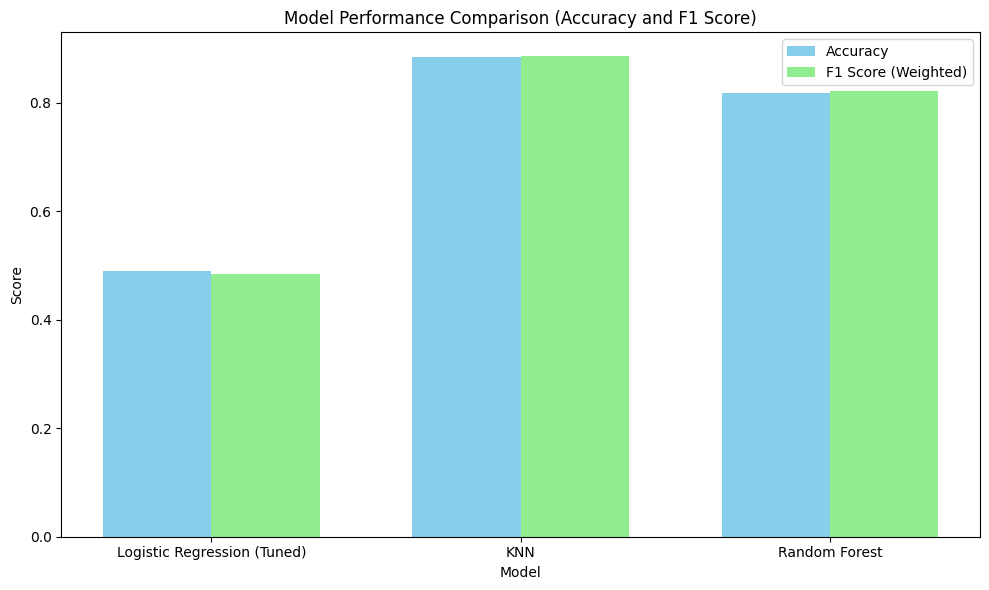

In [93]:
# Collect the performance metrics
model_comparison = {
    'Model': ['Logistic Regression (Tuned)', 'KNN', 'Random Forest'],
    'Accuracy': [accuracy_tuned, accuracy_knn, accuracy_score(y_test, y_pred)],
    'F1 Score (Weighted)': [f1_tuned, f1_knn, f1_score(y_test, y_pred, average='weighted')]
}

# Create a pandas DataFrame for easy comparison
comparison_df = pd.DataFrame(model_comparison)

# Display the comparison table
print("Model Performance Comparison:")
display(comparison_df)

# Optional: Visualize the comparison
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(model_comparison['Model']))

plt.bar(index, comparison_df['Accuracy'], bar_width, label='Accuracy', color='skyblue')
plt.bar(index + bar_width, comparison_df['F1 Score (Weighted)'], bar_width, label='F1 Score (Weighted)', color='lightgreen')

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Performance Comparison (Accuracy and F1 Score)')
plt.xticks(index + bar_width / 2, comparison_df['Model'])
plt.legend()
plt.tight_layout()
plt.show()